# Pilotless OFDM Receiver

Self-contained reproduction of the goodput results for the Explainable Pilotless OFDM Receiver task.

The selected AITE-generated receiver (`selected_solution/solution.py`) is evaluated against three references: perfect-CSI with QAM, pilot-based baseline with QAM, and neural receiver trained jointly with the learned constellation.

The learned constellation used for pilotless communication is available in `eval/constellation_points.pkl`.

Training the end-to-end system (jointly learning the constellation and neural receiver) takes some time. It can be skipped by downloading pre-trained weights from [here](https://drive.google.com/file/d/1yWbJ3Lk-efzLhDkqO5CSOnWW40Nhh6Wr/view?usp=sharing).

## Configuration and Imports

In [1]:
# Import Sionna
import sionna.phy

import math
import numpy as np
import pickle
import os
import gc

import importlib.util
import sys
from contextlib import contextmanager
from pathlib import Path

# For plotting
%matplotlib inline
import matplotlib.pyplot as plt

# For the implementation of the neural receiver
import torch
import torch.nn as nn
import torch.nn.functional as F

from sionna.phy import Block
from sionna.phy.channel.tr38901 import Antenna, AntennaArray, TDL
from sionna.phy.channel import OFDMChannel
from sionna.phy.mimo import StreamManagement
from sionna.phy.ofdm import (
    ResourceGrid,
    ResourceGridMapper,
    ResourceGridDemapper,
    LSChannelEstimator,
    LMMSEEqualizer,
    RemoveNulledSubcarriers,
)
from sionna.phy.utils import ebnodb2no, insert_dims, expand_to_rank, sim_ber
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.mapping import Mapper, Demapper, BinarySource, Constellation

# Set seed for reproducible results
sionna.phy.config.seed = 42
device = sionna.phy.config.device

## Simulation Parameters

In [2]:
NUM_BITS_PER_SYMBOL = 6 # 64-QAM

# Coding rate
CODERATE = 0.7

# Create an RX-TX association matrix.
RX_TX_ASSOCIATION = np.array([[1]])

# Instantiate a StreamManagement object
STREAM_MANAGEMENT = StreamManagement(RX_TX_ASSOCIATION, 1)

NUM_GUARD_CARRIERS = [0,0]
DC_NULL = False
SUBCARRIER_SPACING = 30e3 # Hz
CYCLIC_PREFIX_LENGTH = 0
NUM_OFDM_SYMBOLS = 14
FFT_SIZE = 72


# Resource grid configuration without DMRS pilots
RESOURCE_GRID_0P = ResourceGrid(num_ofdm_symbols=NUM_OFDM_SYMBOLS,
                                fft_size=FFT_SIZE,
                                subcarrier_spacing=SUBCARRIER_SPACING,
                                num_tx=1,
                                num_streams_per_tx=1,
                                cyclic_prefix_length=CYCLIC_PREFIX_LENGTH,
                                num_guard_carriers=NUM_GUARD_CARRIERS,
                                dc_null=DC_NULL)

# Resource grid configuration with two DMRS pilots for baseline comparison
RESOURCE_GRID_2P = ResourceGrid(num_ofdm_symbols=NUM_OFDM_SYMBOLS,
                                fft_size=FFT_SIZE,
                                subcarrier_spacing=SUBCARRIER_SPACING,
                                num_tx=1,
                                num_streams_per_tx=1,
                                pilot_pattern="kronecker",
                                pilot_ofdm_symbol_indices=[2,11],
                                cyclic_prefix_length=CYCLIC_PREFIX_LENGTH,
                                num_guard_carriers=NUM_GUARD_CARRIERS,
                                dc_null=DC_NULL)

# Carrier frequency in Hz.
CARRIER_FREQUENCY = 2.6e9

# Antenna setting
UT_ARRAY = Antenna(polarization="single",
                   polarization_type="V",
                   antenna_pattern="omni",
                   carrier_frequency=CARRIER_FREQUENCY)
BS_ARRAY = AntennaArray(num_rows=1,
                        num_cols=1,
                        polarization="single",
                        polarization_type="V",
                        antenna_pattern="omni",
                        carrier_frequency=CARRIER_FREQUENCY)

# Nominal delay spread in [s]. Please see the TDL documentation
# about how to choose this value.
DELAY_SPREAD = 100e-9

# The `direction` determines if the UT or BS is transmitting.
# In the `uplink`, the UT is transmitting.
DIRECTION = "uplink"

# UT speed [m/s]. BSs are always assumed to be fixed.
# The direction of travel will chosen randomly within the x-y plane.
SPEED = 3.0

# Configure a channel impulse response (CIR) generator for the TDL model.
CHANNEL_MODEL_TRAIN = TDL(model="C",
                          delay_spread=DELAY_SPREAD,
                          carrier_frequency=CARRIER_FREQUENCY,
                          min_speed=0.0,
                          max_speed=SPEED)

# Configure a channel impulse response (CIR) generator for the TDL model.
CHANNEL_MODEL_EVAL = {"TDL A" : TDL(model="A",
                           delay_spread=DELAY_SPREAD,
                           carrier_frequency=CARRIER_FREQUENCY,
                           min_speed=0.0,
                           max_speed=SPEED),
                      "TDL D" : TDL(model="D",
                           delay_spread=DELAY_SPREAD,
                           carrier_frequency=CARRIER_FREQUENCY,
                           min_speed=0.0,
                           max_speed=SPEED)}

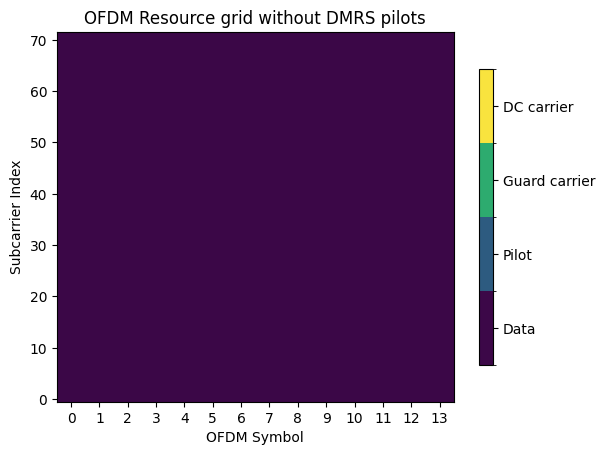

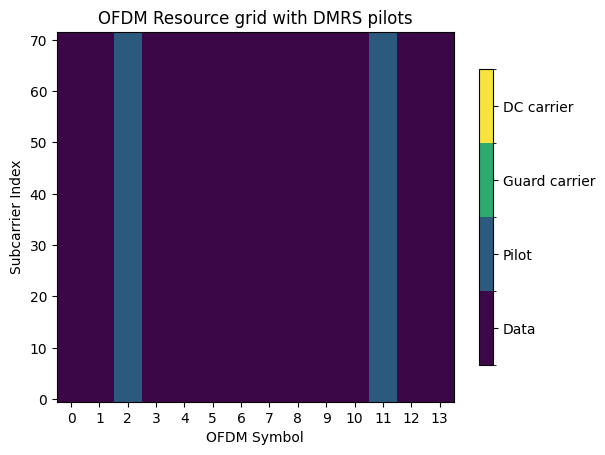

In [3]:
# Resource grid without DMRS pilots
plot = RESOURCE_GRID_0P.show();
plt.title("OFDM Resource grid without DMRS pilots");

# Resource grid with DMRS pilots
plot = RESOURCE_GRID_2P.show();
plt.title("OFDM Resource grid with DMRS pilots");

## Neural Receiver

### Definition of the neural receiver

In [4]:
NUM_CONV_CHANNELS = 128

In [5]:
class ResidualBlock(nn.Module):
    """
    Convolutional residual block with two convolutional layers, ReLU activation,
    layer normalization, and a skip connection.

    The number of convolutional channels of the input must match NUM_CONV_CHANNELS
    for the skip connection to work.

    Input shape: [batch_size, NUM_CONV_CHANNELS, num_ofdm_symbols, num_subcarriers]
    Output shape: [batch_size, NUM_CONV_CHANNELS, num_ofdm_symbols, num_subcarriers]
    """

    def __init__(self, num_ofdm_symbols: int, fft_size: int, kernel_size: tuple[int, int] = (3, 3), dilation: tuple[int, int] = (1, 1)):
        super().__init__()

        # Layer normalization over the last three dimensions (C, H, W)
        self._layer_norm_1 = nn.LayerNorm([NUM_CONV_CHANNELS, num_ofdm_symbols, fft_size])
        self._conv_1_dw = nn.Conv2d(
            in_channels=NUM_CONV_CHANNELS,
            out_channels=NUM_CONV_CHANNELS,
            kernel_size=kernel_size,
            padding=dilation,
            dilation=dilation,
            groups=NUM_CONV_CHANNELS,  # depthwise: one filter per channel
        )
        self._conv_1_pw = nn.Conv2d(
            in_channels=NUM_CONV_CHANNELS,
            out_channels=NUM_CONV_CHANNELS,
            kernel_size=1,             # pointwise: mixes channels
        )
        self._layer_norm_2 = nn.LayerNorm([NUM_CONV_CHANNELS, num_ofdm_symbols, fft_size])
        self._conv_2_dw = nn.Conv2d(
            in_channels=NUM_CONV_CHANNELS,
            out_channels=NUM_CONV_CHANNELS,
            kernel_size=kernel_size,
            padding=dilation,
            dilation=dilation,
            groups=NUM_CONV_CHANNELS,  # depthwise: one filter per channel
        )
        self._conv_2_pw = nn.Conv2d(
            in_channels=NUM_CONV_CHANNELS,
            out_channels=NUM_CONV_CHANNELS,
            kernel_size=1,             # pointwise: mixes channels
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        z = self._layer_norm_1(inputs)
        z = F.relu(z)
        z = self._conv_1_pw(self._conv_1_dw(z))
        z = self._layer_norm_2(z)
        z = F.relu(z)
        z = self._conv_2_pw(self._conv_2_dw(z))
        # Skip connection
        z = z + inputs
        return z


class NeuralReceiver(nn.Module):
    """
    Residual convolutional neural receiver.

    This neural receiver is fed with the post-DFT received samples, forming a
    resource grid of size num_ofdm_symbols x fft_size, and computes LLRs on
    the transmitted coded bits.

    Input
    -----
    y : [batch_size, num_rx, num_rx_antenna, num_ofdm_symbols, num_subcarriers], complex
        Received post-DFT samples.
    no : [batch_size], float
        Noise variance.

    Output
    ------
    llr : [batch_size, 1, 1, num_ofdm_symbols, num_subcarriers, num_bits_per_symbol], float
        LLRs on the transmitted bits.
    """

    def __init__(
        self,
        num_bits_per_symbol: int,
        num_ofdm_symbols: int,
        fft_size: int,
    ):
        super().__init__()
        self._num_bits_per_symbol = num_bits_per_symbol
        self._num_ofdm_symbols = num_ofdm_symbols
        self._fft_size = fft_size

        # Input convolution: 2*num_rx_antenna + 1 input channels (real, imag, noise)
        # For single antenna: 2*1 + 1 = 3 input channels
        num_input_channels = 2 * 1 + 1
        self._input_conv = nn.Conv2d(
            in_channels=num_input_channels,
            out_channels=NUM_CONV_CHANNELS,
            kernel_size=3,
            padding=1,
        )
        # Residual blocks
        self._res_block_1 = ResidualBlock(num_ofdm_symbols, fft_size, kernel_size=(3, 3), dilation=(1, 1))
        self._res_block_2 = ResidualBlock(num_ofdm_symbols, fft_size, kernel_size=(3, 3), dilation=(1, 2))
        self._res_block_3 = ResidualBlock(num_ofdm_symbols, fft_size, kernel_size=(3, 3), dilation=(2, 4))
        self._res_block_4 = ResidualBlock(num_ofdm_symbols, fft_size, kernel_size=(3, 3), dilation=(3, 8))
        self._res_block_5 = ResidualBlock(num_ofdm_symbols, fft_size, kernel_size=(3, 3), dilation=(1, 1))
        # Output convolution
        self._output_conv = nn.Conv2d(
            in_channels=NUM_CONV_CHANNELS,
            out_channels=num_bits_per_symbol,
            kernel_size=3,
            padding=1,
        )

    @torch.compiler.disable
    def _preprocess(self, y: torch.Tensor, no: torch.Tensor) -> torch.Tensor:
        """Complex -> real feature map. Runs eager (graph break under compile)."""
        y = y.squeeze(1)  # [B, num_rx_ant, T, F], complex
        no_log = torch.log10(no)
        b, _, t, f = y.shape
        no_expanded = no_log.view(-1, 1, 1, 1).expand(b, 1, t, f)
        return torch.cat([y.real, y.imag, no_expanded], dim=1)  # [B, 3, T, F]

    def _run_cnn(self, z: torch.Tensor) -> torch.Tensor:
        z = self._input_conv(z)
        z = self._res_block_1(z)
        z = self._res_block_2(z)
        z = self._res_block_3(z)
        z = self._res_block_4(z)
        z = self._res_block_5(z)
        return self._output_conv(z)

    def forward(self, y: torch.Tensor, no: torch.Tensor) -> torch.Tensor:
        z = self._preprocess(y, no)
        z = self._run_cnn(z)
        z = z.permute(0, 2, 3, 1)
        return insert_dims(z, 2, 1)

### E2E system

In [6]:
class OFDMSystemNeuralReceiver(Block):
    """
    End-to-end OFDM system with neural receiver

    When training=True, returns the BMD rate loss for training.
    When training=False, returns (bits, bits_hat) for BLERs evaluation.
    """

    def __init__(self, channel_model, training: bool = False):
        super().__init__()
        self._training = training

        n = int(RESOURCE_GRID_0P.num_data_symbols * NUM_BITS_PER_SYMBOL)
        k = int(n * CODERATE)
        self._k = k
        self._n = n

        # Transmitter components
        self._binary_source = BinarySource()
        if not training:
            self._encoder = LDPC5GEncoder(k, n)
        self._rg_mapper = ResourceGridMapper(RESOURCE_GRID_0P)

        # Trainable constellation
        qam_points = Constellation("qam", NUM_BITS_PER_SYMBOL).points
        self.points_r = nn.Parameter(qam_points.real.clone())
        self.points_i = nn.Parameter(qam_points.imag.clone())
        self.constellation = Constellation("custom",
                                        NUM_BITS_PER_SYMBOL,
                                        points=torch.complex(self.points_r, self.points_i),
                                        normalize=True,
                                        center=True)
        self._mapper = Mapper(constellation=self.constellation)

        # Channel
        self._channel = OFDMChannel(
            channel_model,
            RESOURCE_GRID_0P,
            add_awgn=True,
            normalize_channel=True,
            return_channel=False,
        )

        # Neural receiver
        self._neural_receiver = NeuralReceiver(
            NUM_BITS_PER_SYMBOL,
            NUM_OFDM_SYMBOLS,
            FFT_SIZE,
        )

        # Resource grid demapper
        self._rg_demapper = ResourceGridDemapper(RESOURCE_GRID_0P, STREAM_MANAGEMENT)

        # Decoder (only for evaluation)
        if not training:
            self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)

    def _transmit(self, batch_size: int, ebno_db: torch.Tensor):
        """Run the TX + channel pipeline and return ``(y, no)``."""
        no = ebnodb2no(
            ebno_db,
            num_bits_per_symbol=NUM_BITS_PER_SYMBOL,
            coderate=CODERATE,
            resource_grid=RESOURCE_GRID_0P,
        )
        if no.dim() == 0:
            no = no.expand(batch_size)

        bits = self._binary_source([batch_size, 1, 1, self._k])
        codewords = self._encoder(bits)

        x = self._mapper(codewords)
        x_rg = self._rg_mapper(x)

        no_expanded = expand_to_rank(no, x_rg.ndim)
        y = self._channel(x_rg, no_expanded)
        return bits, y, no

    def forward(self, batch_size: int, ebno_db: torch.Tensor):
        # Compute noise power
        no = ebnodb2no(
            ebno_db,
            num_bits_per_symbol=NUM_BITS_PER_SYMBOL,
            coderate=CODERATE,
            resource_grid=RESOURCE_GRID_0P,
        )

        # Ensure no has shape [batch_size]
        if no.dim() == 0:
            no = no.expand(batch_size)

        # Update constellation points from trainable parameters (creates fresh graph)
        self.constellation.points = torch.complex(self.points_r, self.points_i)

        # Transmitter
        if self._training:
            # Skip outer coding during training
            codewords = self._binary_source([batch_size, 1, 1, self._n])
        else:
            bits = self._binary_source([batch_size, 1, 1, self._k])
            codewords = self._encoder(bits)

        # Map data to constellation symbols
        x = self._mapper(codewords)
        # Map symbols to resource grid
        x_rg = self._rg_mapper(x)

        # Channel
        no_expanded = expand_to_rank(no, x_rg.ndim)
        y = self._channel(x_rg, no_expanded)

        # Receiver
        llr = self._neural_receiver(y, no)
        llr = self._rg_demapper(llr)  # Extract data-carrying resource elements
        llr = llr.reshape(batch_size, 1, 1, self._n)

        if self._training:
            # Compute BCE loss for BMD rate
            bce = F.binary_cross_entropy_with_logits(
                llr, codewords.float(), reduction="none"
            )
            bce = bce.mean()
            # BMD rate
            rate = 1.0 - bce / math.log(2.0)
            return rate
        else:
            # Decode
            bits_hat = self._decoder(llr)
            return bits, bits_hat

### Training

In [ ]:
BATCH_SIZE_TRAIN = 128

EBN0_DB_MIN = 13.0
EBN0_DB_MAX = 25.0

NUM_TRAINING_ITERATIONS = 100000

In [ ]:
from IPython.display import display, clear_output

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
line, = ax.plot([], [])
ax.set_xlabel("Iteration")
ax.set_ylabel("Rate (bit)")
ax.set_title("Training Progress")
ax.grid(True)
display(fig)

model = OFDMSystemNeuralReceiver(CHANNEL_MODEL_TRAIN, training=True).to(device)


optimizer = torch.optim.Adam([
    {'params': model._neural_receiver.parameters(), 'lr': 1e-3},
    {'params': [model.points_r, model.points_i], 'lr': 1e-4},
])

iterations = []
rates = []

model.train()
for i in range(NUM_TRAINING_ITERATIONS):
    ebno_db = torch.empty(BATCH_SIZE_TRAIN, device=device).uniform_(EBN0_DB_MIN, EBN0_DB_MAX)
    
    optimizer.zero_grad()
    rate = model(BATCH_SIZE_TRAIN, ebno_db)
    
    loss = -rate
    loss.backward()
    optimizer.step()
    
    if i % 100 == 0:
        iterations.append(i)
        rates.append(rate.item())
        line.set_data(iterations, rates)
        ax.set_xlim(0, max(i, 1))
        ax.set_ylim(min(rates) - 0.1, max(rates) + 0.1)
        clear_output(wait=True)
        display(fig)
        print(f"{i}/{NUM_TRAINING_ITERATIONS}  Rate: {rate.item():.2E} bit")

torch.save(model.state_dict(), 'weights-pilotless.pt')

## Agent receiver

In [9]:
@contextmanager
def _chdir(path):
    """Temporarily change process cwd (for relative opens in agent solutions)."""
    old = os.getcwd()
    os.chdir(str(path))
    try:
        yield
    finally:
        os.chdir(old)


_LINK_CONFIG_NAMES = (
    "NUM_BITS_PER_SYMBOL",
    "NUM_OFDM_SYMBOLS",
    "FFT_SIZE",
    "SUBCARRIER_SPACING",
    "CYCLIC_PREFIX_LENGTH",
    "NUM_GUARD_CARRIERS",
    "DC_NULL",
    "CODERATE",
    "CARRIER_FREQUENCY",
)


def _ensure_workspace_assets(workspace_dir: Path, pilotless_dir: Path) -> None:
    """Stage files solution.py expects next to itself."""
    pkl_dst = workspace_dir / "constellation_points.pkl"
    if not pkl_dst.exists():
        pkl_src = pilotless_dir / "eval" / "constellation_points.pkl"
        if not pkl_src.exists():
            raise FileNotFoundError(
                f"Missing {pkl_dst} and no source at {pkl_src}"
            )
        import shutil
        shutil.copy2(pkl_src, pkl_dst)


def _inject_link_config() -> None:
    """Stub link_config from notebook globals only; missing names stay None."""
    import types

    lc = types.ModuleType("link_config")
    for name in _LINK_CONFIG_NAMES:
        setattr(lc, name, globals().get(name))

    sys.modules["link_config"] = lc


def _load_receiver_class(filename: str):
    """
    Import an eval-style solution (receiver(y, no)) and return
    (wrapper_class, workspace_dir).
    """
    src = Path(filename).resolve()
    if not src.is_file():
        raise FileNotFoundError(src)

    workspace_dir = src.parent
    pilotless_dir = Path.cwd()

    _ensure_workspace_assets(workspace_dir, pilotless_dir)

    if str(workspace_dir) not in sys.path:
        sys.path.insert(0, str(workspace_dir))

    _inject_link_config()

    mod_name = src.stem.replace("-", "_")
    spec = importlib.util.spec_from_file_location(mod_name, str(src))
    if spec is None or spec.loader is None:
        raise ImportError(f"Cannot load {src}")

    module = importlib.util.module_from_spec(spec)
    sys.modules[mod_name] = module

    import hp as hp_mod
    hp_mod.HP._params = {}
    hp_mod.HP._loaded = True

    with _chdir(workspace_dir):
        spec.loader.exec_module(module)

    fn = getattr(module, "receiver", None)
    if not callable(fn):
        raise RuntimeError(f"{filename} must define a callable receiver(y, no)")

    class AgentReceiverWrapper(nn.Module):
        def __init__(self, num_bits_per_symbol):
            super().__init__()
            self._receiver = fn

        def forward(self, y, no):
            return self._receiver(y, no)

    return AgentReceiverWrapper, workspace_dir

In [10]:
class OFDMSystemAgent(Block):
    """End-to-end OFDM eval system using a receiver loaded from a solution file."""

    def __init__(self, channel_model, receiver_filename: str):
        super().__init__()

        n = int(RESOURCE_GRID_0P.num_data_symbols * NUM_BITS_PER_SYMBOL)
        k = int(n * CODERATE)
        self._k = k
        self._n = n

        self._binary_source = BinarySource()
        self._encoder = LDPC5GEncoder(k, n)
        self._rg_mapper = ResourceGridMapper(RESOURCE_GRID_0P)

        with open("eval/constellation_points.pkl", "rb") as f:
            init_points = pickle.load(f)
        init_points = torch.as_tensor(np.asarray(init_points, dtype=np.complex64))
        self.points_r = nn.Parameter(init_points.real.clone(), requires_grad=False)
        self.points_i = nn.Parameter(init_points.imag.clone(), requires_grad=False)
        self.constellation = Constellation(
            "custom", NUM_BITS_PER_SYMBOL,
            points=torch.complex(self.points_r, self.points_i),
            normalize=True, center=True,
        )
        self._mapper = Mapper(constellation=self.constellation)

        self._channel = OFDMChannel(
            channel_model, RESOURCE_GRID_0P,
            add_awgn=True, normalize_channel=True, return_channel=False,
        )

        receiver_cls, pilotless_dir = _load_receiver_class(receiver_filename)
        with _chdir(pilotless_dir):
            self._agent_receiver = receiver_cls(NUM_BITS_PER_SYMBOL)

        self._rg_demapper = ResourceGridDemapper(RESOURCE_GRID_0P, STREAM_MANAGEMENT)
        self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)

        self._RESOURCE_GRID_0P = RESOURCE_GRID_0P
        self._NUM_BITS_PER_SYMBOL = NUM_BITS_PER_SYMBOL
        self._CODERATE = CODERATE

    def forward(self, batch_size: int, ebno_db: torch.Tensor):
        no = ebnodb2no(
            ebno_db,
            num_bits_per_symbol=self._NUM_BITS_PER_SYMBOL,
            coderate=self._CODERATE,
            resource_grid=self._RESOURCE_GRID_0P,
        )
        if no.dim() == 0:
            no = no.expand(batch_size)

        bits = self._binary_source([batch_size, 1, 1, self._k])
        codewords = self._encoder(bits)

        x    = self._mapper(codewords)
        x_rg = self._rg_mapper(x)
        no_expanded = expand_to_rank(no, x_rg.ndim)
        y = self._channel(x_rg, no_expanded)

        llr = self._agent_receiver(y, no)
        llr = self._rg_demapper(llr)
        llr = llr.reshape(batch_size, 1, 1, self._n)
        bits_hat = self._decoder(llr)
        return bits, bits_hat

## Baselines

In [11]:
class OFDMSystem(Block):
    """
    Baseline OFDM system with conventional channel estimation.

    When perfect_csi=True, uses perfect channel state information.
    When perfect_csi=False, uses LS channel estimation.
    """

    def __init__(self, channel_model, perfect_csi: bool = False):
        super().__init__()
        self._perfect_csi = perfect_csi

        # Resource grid
        rg = RESOURCE_GRID_0P if perfect_csi else RESOURCE_GRID_2P
        self._rg = rg

        n = int(rg.num_data_symbols * NUM_BITS_PER_SYMBOL)
        k = int(n * CODERATE)
        self._k = k

        # Transmitter components
        self._binary_source = BinarySource()
        self._encoder = LDPC5GEncoder(k, n)
        self._mapper = Mapper("qam", NUM_BITS_PER_SYMBOL)
        self._rg_mapper = ResourceGridMapper(rg)

        # Channel
        self._channel = OFDMChannel(
            channel_model,
            rg,
            add_awgn=True,
            normalize_channel=True,
            return_channel=True,
        )

        # Receiver components
        if perfect_csi:
            self._removed_null_subc = RemoveNulledSubcarriers(rg)
        else:
            self._ls_est = LSChannelEstimator(rg, interpolation_type="nn")

        self._lmmse_equ = LMMSEEqualizer(rg, STREAM_MANAGEMENT)
        self._demapper = Demapper("app", "qam", NUM_BITS_PER_SYMBOL)
        self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)
    
    def _receiver(self, y, no, h_freq=None):
        if self._perfect_csi:
            h_hat = self._removed_null_subc(h_freq)
            err_var = 0.0
        else:
            h_hat, err_var = self._ls_est(y, no)

        x_hat, no_eff = self._lmmse_equ(y, h_hat, err_var, no)
        no_eff_expanded = expand_to_rank(no_eff, x_hat.ndim)
        llr = self._demapper(x_hat, no_eff_expanded)
        return llr

    def forward(self, batch_size: int, ebno_db: torch.Tensor):
        # Compute noise power
        no = ebnodb2no(
            ebno_db,
            num_bits_per_symbol=NUM_BITS_PER_SYMBOL,
            coderate=CODERATE,
            resource_grid=self._rg,
        )

        # Transmitter
        bits = self._binary_source([batch_size, 1, self._rg.num_streams_per_tx, self._k])
        codewords = self._encoder(bits)
        x = self._mapper(codewords)
        x_rg = self._rg_mapper(x)

        # Channel
        no_expanded = expand_to_rank(no, x_rg.ndim)
        y, h_freq = self._channel(x_rg, no_expanded)

        # Receiver
        llr = self._receiver(y, no, h_freq)
        bits_hat = self._decoder(llr)

        return bits, bits_hat

## Evaluations

In [ ]:
# Minimum value of Eb/N0 [dB] for simulations
EBN0_DB_MIN_EVAL = 5.0

# Maximum value of Eb/N0 [dB] for simulations
EBN0_DB_MAX_EVAL = 25.0

NUM_TARGET_BLOCK_ERRORS = 100
MAX_MC_ITER = 100
BATCH_SIZE_EVAL = 64

SNR_POINTS_EVAL = np.linspace(EBN0_DB_MIN_EVAL, EBN0_DB_MAX_EVAL, 20)

AGENT_SOLUTION_FILE = "selected_solution/solution.py"


In [13]:
BLERs = {}
for key in CHANNEL_MODEL_EVAL.keys():
    BLERs[key] = {}

### Baselines

In [14]:
for key, channel_model in CHANNEL_MODEL_EVAL.items():
    baseline_ls = OFDMSystem(channel_model, False).to(device)
    _, bler = sim_ber(baseline_ls,
                            ebno_dbs=SNR_POINTS_EVAL,
                            batch_size=BATCH_SIZE_EVAL,
                            num_target_block_errors=NUM_TARGET_BLOCK_ERRORS,
                            target_bler=1e-3,
                            max_mc_iter=MAX_MC_ITER)
    BLERs[key]['Baseline: LS Estimation'] = bler.cpu().numpy()
    del bler, baseline_ls

    baseline_pcsi = OFDMSystem(channel_model, True).to(device)
    _, bler = sim_ber(baseline_pcsi,
                            ebno_dbs=SNR_POINTS_EVAL,
                            batch_size=BATCH_SIZE_EVAL,
                            num_target_block_errors=NUM_TARGET_BLOCK_ERRORS,
                            target_bler=1e-3,
                            max_mc_iter=MAX_MC_ITER)
    BLERs[key]['Baseline: Perfect CSI'] = bler.cpu().numpy()
    del bler, baseline_pcsi
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      5.0 | 2.3335e-01 | 1.0000e+00 |      108362 |      464384 |          128 |         128 |         0.3 |reached target block errors
    6.053 | 2.1265e-01 | 1.0000e+00 |       98751 |      464384 |          128 |         128 |         0.1 |reached target block errors
    7.105 | 1.9283e-01 | 1.0000e+00 |       89545 |      464384 |          128 |         128 |         0.1 |reached target block errors
    8.158 | 1.7115e-01 | 1.0000e+00 |       79477 |      464384 |          128 |         128 |         0.1 |reached target block errors
    9.211 | 1.4864e-01 | 1.0000e+00 |       69028 |      464384 |          128 |         128 |         0.1 |reached target block errors
   10.263 | 1.1618e-01 | 1.0000e+00 |       53953 |      464384 |

### Neural receiver

In [15]:
for key, channel_model in CHANNEL_MODEL_EVAL.items():
    # Instantiating the end-to-end model for evaluation
    model = OFDMSystemNeuralReceiver(channel_model, training=False).to(device)

    # Run one inference to initialize the model
    model(BATCH_SIZE_EVAL, torch.tensor(10.0, device=device))

    ckpt = torch.load("weights-pilotless.pt", map_location=device, weights_only=True)
    result = model.load_state_dict(ckpt, strict=False)

    allowed_missing_prefixes = ("_encoder.", "_decoder.")
    unexpected_missing = [k for k in result.missing_keys
                        if not k.startswith(allowed_missing_prefixes)]
    assert not unexpected_missing, f"Missing receiver weights: {unexpected_missing}"
    assert not result.unexpected_keys, f"Unexpected keys in ckpt: {result.unexpected_keys}"

    with torch.no_grad():
        model.constellation.points = torch.complex(model.points_r, model.points_i)

    # Computing and plotting BLERs
    _, bler = sim_ber(model,
                    ebno_dbs=SNR_POINTS_EVAL,
                    batch_size=BATCH_SIZE_EVAL,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS,
                    max_mc_iter=MAX_MC_ITER,
                    target_bler=1e-3)
    BLERs[key]['Constellation shaping + Neural receiver'] = bler.cpu().numpy()
    del bler, model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      5.0 | 2.1795e-01 | 1.0000e+00 |      118092 |      541824 |          128 |         128 |         0.1 |reached target block errors
    6.053 | 1.9315e-01 | 1.0000e+00 |      104652 |      541824 |          128 |         128 |         0.1 |reached target block errors
    7.105 | 1.6893e-01 | 1.0000e+00 |       91531 |      541824 |          128 |         128 |         0.1 |reached target block errors
    8.158 | 1.3734e-01 | 1.0000e+00 |       74412 |      541824 |          128 |         128 |         0.1 |reached target block errors
    9.211 | 9.9237e-02 | 1.0000e+00 |       53769 |      541824 |          128 |         128 |         0.1 |reached target block errors
   10.263 | 3.7516e-02 | 4.9609e-01 |       40654 |     1083648 |

### Agent solution

In [16]:
for key, channel_model in CHANNEL_MODEL_EVAL.items():
    agent_model = OFDMSystemAgent(channel_model, AGENT_SOLUTION_FILE).to(device)
    _, bler = sim_ber(agent_model,
                    ebno_dbs=SNR_POINTS_EVAL,
                    batch_size=BATCH_SIZE_EVAL,
                    num_target_block_errors=NUM_TARGET_BLOCK_ERRORS,
                    target_bler=1e-3,
                    max_mc_iter=MAX_MC_ITER)
    BLERs[key][f'Agent receiver'] = bler.cpu().numpy()
    del bler, agent_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      5.0 | 2.1816e-01 | 1.0000e+00 |      118207 |      541824 |          128 |         128 |         0.3 |reached target block errors
    6.053 | 1.9217e-01 | 1.0000e+00 |      104121 |      541824 |          128 |         128 |         0.3 |reached target block errors
    7.105 | 1.6630e-01 | 1.0000e+00 |       90108 |      541824 |          128 |         128 |         0.3 |reached target block errors
    8.158 | 1.4074e-01 | 1.0000e+00 |       76258 |      541824 |          128 |         128 |         0.3 |reached target block errors
    9.211 | 9.1321e-02 | 9.8438e-01 |       49480 |      541824 |          126 |         128 |         0.3 |reached target block errors
   10.263 | 4.1101e-02 | 4.2969e-01 |       44539 |     1083648 |

### Save results

In [17]:
with open('blers.pkl', 'wb') as f:
    pickle.dump([SNR_POINTS_EVAL, BLERs], f)

### Load and compute goodputs

In [18]:
def bler_2_goodput(rg, bler):
    n_re = rg.num_resource_elements # Number of resource elements
    k = int(rg.num_data_symbols*NUM_BITS_PER_SYMBOL * CODERATE) # Number of information bits per resource grid
    g = (1.-bler)*k/n_re # Goodput
    return g

In [19]:
with open('blers.pkl', 'rb') as f:
    SNR_POINTS_EVAL, BLERs = pickle.load(f)

GOODPUTS = {}
for key in CHANNEL_MODEL_EVAL.keys():
    GOODPUTS[key] = {}

# Baselines
for key, channel_model in CHANNEL_MODEL_EVAL.items():
    GOODPUTS[key]['Baseline: LS Estimation'] = bler_2_goodput(RESOURCE_GRID_2P, BLERs[key]['Baseline: LS Estimation'])
    GOODPUTS[key]['Baseline: Perfect CSI'] = bler_2_goodput(RESOURCE_GRID_0P, BLERs[key]['Baseline: Perfect CSI'])
    GOODPUTS[key]['Constellation shaping + Neural receiver'] = bler_2_goodput(RESOURCE_GRID_0P, BLERs[key]['Constellation shaping + Neural receiver'])
    GOODPUTS[key]['Agent receiver'] = bler_2_goodput(RESOURCE_GRID_0P, BLERs[key]['Agent receiver'])

### Plot

In [20]:
COLOR_MAP = {
    "Baseline: Perfect CSI":                    "black",
    "Baseline: LS Estimation":                  "C0",
    "Constellation shaping + Neural receiver":  "C6",
    "Agent receiver":                         "C1",
}

MARKERS = {
    "Baseline: Perfect CSI":                    "o",
    "Baseline: LS Estimation":                  "x",
    "Constellation shaping + Neural receiver":  "s",
    "Agent receiver":                         "v",
}

LINESTYLES = {
    "Baseline: Perfect CSI":                    "-",
    "Baseline: LS Estimation":                  "-",
    "Constellation shaping + Neural receiver":  "-",
    "Agent receiver":                         "--",
}

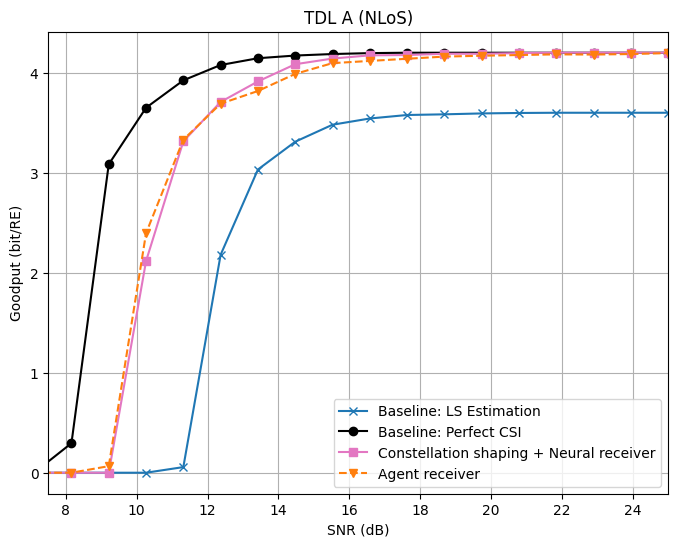

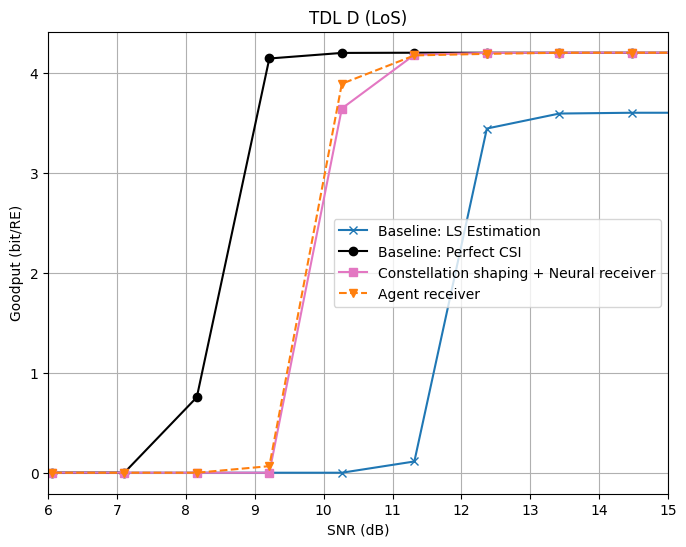

In [21]:
#### TDL A ####

plt.figure(figsize=(8, 6))
for label, gps in GOODPUTS["TDL A"].items(): 
    plt.plot(SNR_POINTS_EVAL, gps, label=label,
                    marker=MARKERS[label], linestyle=LINESTYLES[label], color=COLOR_MAP[label])
plt.xlabel('SNR (dB)')
plt.ylabel('Goodput (bit/RE)')
plt.title(f'TDL A (NLoS)')
plt.xlim(7.5, 25)
plt.legend()
plt.grid(True)


#### TDL D ####

plt.figure(figsize=(8, 6))
for label, gps in GOODPUTS["TDL D"].items():
    plt.plot(SNR_POINTS_EVAL, gps, label=label,
                    marker=MARKERS[label], linestyle=LINESTYLES[label], color=COLOR_MAP[label])
plt.xlabel('SNR (dB)')
plt.ylabel('Goodput (bit/RE)')
plt.title(f'TDL D (LoS)')
plt.xlim(6, 15)
plt.legend()
plt.grid(True)